<h1 style="text-align: center;">dog_cat_classification_transfer_learning</h1>

In this project, we build a binary image classifier to distinguish between cats and dogs.
We will use transfer learning with a pretrained EfficientNet model to achieve strong performance with limited training time.

Imports ans load data

In [3]:
#install and import required libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

print("TensorFlow:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices("GPU"))

import warnings
warnings.filterwarnings("ignore")

TensorFlow: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
#load cats_vs_dogs dataset from TFDS
(ds_train, ds_test), ds_info = tfds.load(
    "cats_vs_dogs",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

ds_info

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.XQT74B_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings (Conference){asirra-a-captcha-that-exploits-interest-aligned-manual-image-categorization,
    author = {Elson, Jeremy and Douceur, Jo

EDA - Exploratory Data Analysis

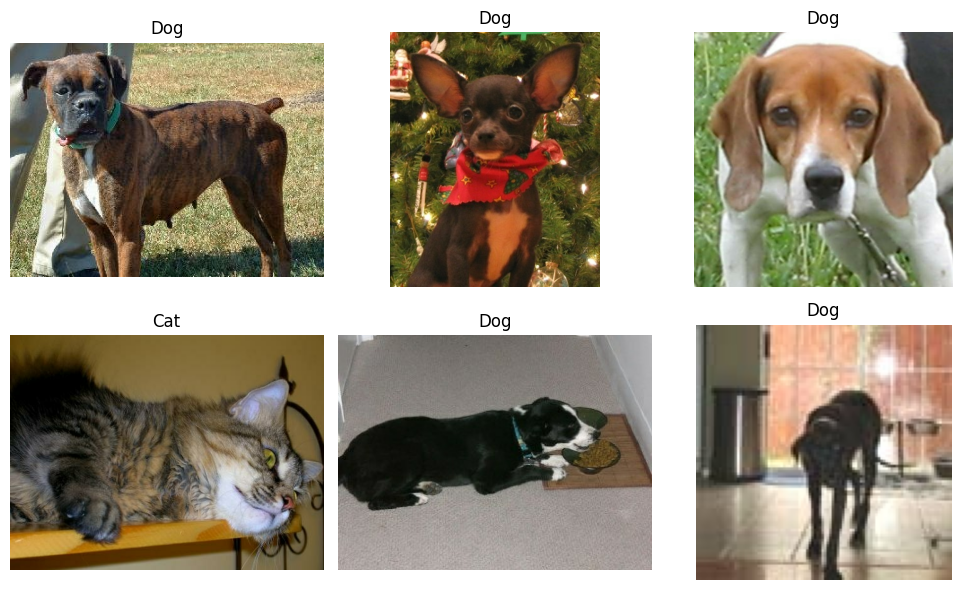

In [5]:
#visualize samples
plt.figure(figsize=(10,6))

for i, (img, label) in enumerate(ds_train.take(6)):
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title("Dog" if label.numpy() == 1 else "Cat")
    plt.axis("off")

plt.tight_layout()
plt.show()

Preprocessing

In [6]:
#define training parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [7]:
#preprocess images for EfficientNet
from tensorflow.keras.applications.efficientnet import preprocess_input

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

def preprocess(image, label, augment=False):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    if augment:
        image = data_augmentation(image)

    # EfficientNet preprocessing (IMPORTANT)
    image = preprocess_input(image)
    return image, label

In [8]:
#build training and validation pipelines
train_ds = ds_train.map(lambda x, y: preprocess(x, y, augment=True), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = ds_test.map(lambda x, y: preprocess(x, y, augment=False), num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [9]:

for images, labels in train_ds.take(1):
    print(images.shape, labels.shape)

(32, 224, 224, 3) (32,)


Images were resized to 224×224 and normalized to [0,1].
The dataset was batched and prefetched to optimize GPU training performance.

Modeling

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

# Base Model
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

#Modell zusammenbauen
model = models.Model(inputs, outputs)

#Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [11]:
#Training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 264s 389ms/step - accuracy: 0.9367 - loss: 0.1772 - val_accuracy: 0.9908 - val_loss: 0.0318
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 203s 331ms/step - accuracy: 0.9871 - loss: 0.0403 - val_accuracy: 0.9912 - val_loss: 0.0267
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 201s 329ms/step - accuracy: 0.9862 - loss: 0.0367 - val_accuracy: 0.9920 - val_loss: 0.0239
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 199s 328ms/step - accuracy: 0.9895 - loss: 0.0289 - val_accuracy: 0.9923 - val_loss: 0.0227
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 204s 334ms/step - accuracy: 0.9894 - loss: 0.0316 - val_accuracy: 0.9920 - val_loss: 0.0216


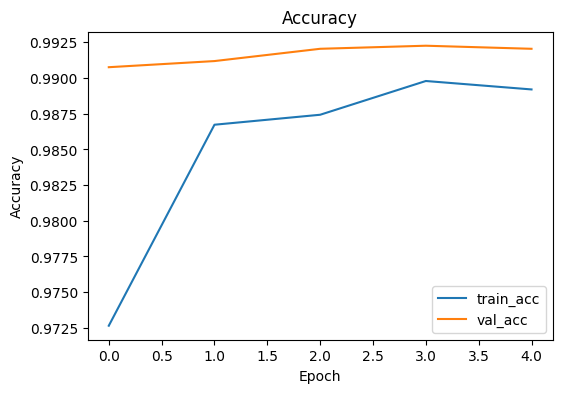

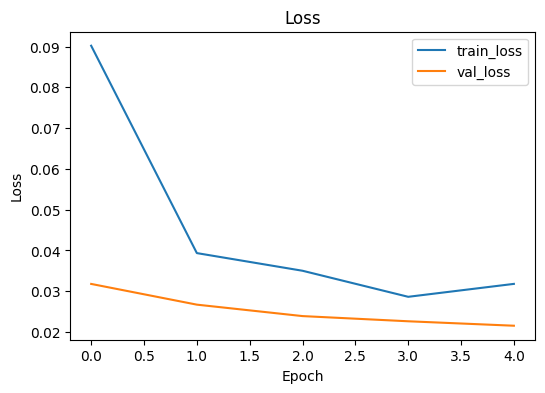

In [13]:
#plot training curves
plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [14]:
 #evaluate on validation set
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
val_loss, val_acc

(0.021594112738966942, 0.9926913380622864)

Conclusion: In this project, i trained a binary image classifier to distinguish cats and dogs using transfer learning with EfficientNetB0.
After applying the correct EfficientNet preprocessing and a lightweight augmentation pipeline, the model achieved excellent validation performance (≈99% accuracy).

In [15]:
# Save model in the new Keras format (recommended)
import os
os.makedirs("models", exist_ok=True)

model.save("models/dog_cat_efficientnetb0.keras")

In [16]:
#Save class mapping
import json

class_map = {0: "cat", 1: "dog"}

with open("models/class_map.json", "w") as f:
  json.dump(class_map, f)